In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report,confusion_matrix,silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.cluster import KMeans

In [96]:
data={"StudyHours":np.random.choice([4,1,5,2,3,1,7],100),"Marks":np.random.randint(0,100,100)}
df=pd.DataFrame(data)
df["Result"]=df["Marks"].apply(lambda x:1 if x>50 else 0)
df.head()

,StudyHours,Marks,Result
0,1,46,0
1,1,51,1
2,3,10,0
3,7,18,0
4,4,25,0


In [97]:
df["Result"].value_counts()

,count
Result,
0,54
1,46


In [98]:
x=df.drop("Result",axis=1)
y=df["Result"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [99]:
wcss=[]
for i in range(1,6):
  km=KMeans(n_clusters=i,random_state=42)
  km.fit(x)
  wcss.append(km.inertia_)

In [111]:
for i in range(2,6):
  km=KMeans(n_clusters=i,random_state=42)
  km.fit(x)
  print(f"Silhouette Score for {i} clusters: {silhouette_score(x,km.labels_)}")

Silhouette Score for 2 clusters: 0.5989880195764102
Silhouette Score for 3 clusters: 0.5937587705749904
Silhouette Score for 4 clusters: 0.560908700904013
Silhouette Score for 5 clusters: 0.5578988336400006


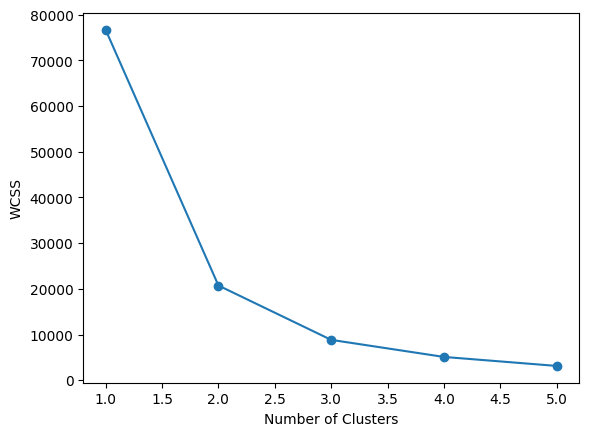

In [100]:
plt.figure()
plt.plot(range(1,6),wcss,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [101]:
km=KMeans(n_clusters=2,random_state=42)
df["Cluster"]=km.fit_predict(x)
centroids=km.cluster_centers_
cluster=df["Cluster"].values

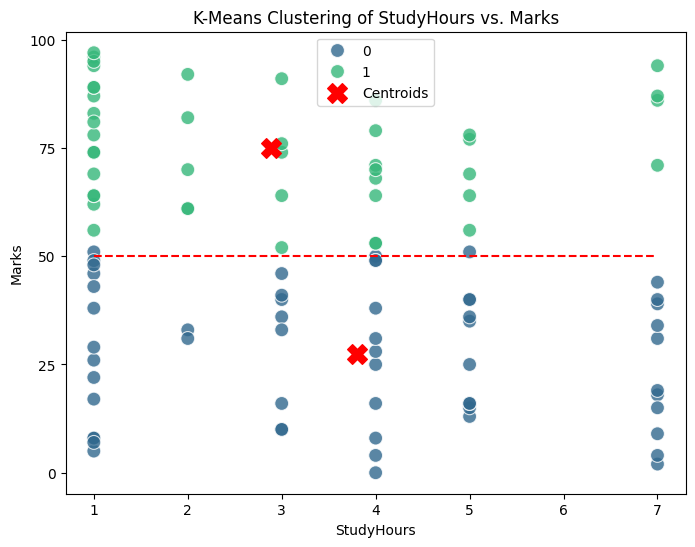

In [110]:
plt.figure(figsize=(8, 6))
sb.scatterplot(x='StudyHours', y='Marks', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.8)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering of StudyHours vs. Marks')
plt.xlabel('StudyHours')
plt.ylabel('Marks')
plt.yticks(range(0, 101, 25))
plt.plot(range(1,8,1),[50]*7,'r--')
plt.legend()
plt.show()